In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df  = pd.read_csv("credit_risk - credit_risk.csv")
df.head()

,age,income,credit_history,loan_amount,credit_risk
0,53,87,Fair,22,0
1,39,51,Good,9,0
2,32,108,Good,29,0
3,45,76,Good,6,0
4,43,71,Good,14,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             200 non-null    int64
 1   income          200 non-null    int64
 2   credit_history  200 non-null    str  
 3   loan_amount     200 non-null    int64
 4   credit_risk     200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,age,income,loan_amount,credit_risk
count,200.000000,200.000000,200.000000,200.000000
mean,41.865000,93.930000,26.030000,0.300000
std,10.590921,31.797018,12.880943,0.459408
min,25.000000,41.000000,5.000000,0.000000
25%,32.000000,66.000000,15.000000,0.000000
50%,42.000000,91.000000,26.000000,0.000000
75%,51.000000,125.000000,37.000000,1.000000
max,59.000000,149.000000,49.000000,1.000000


In [9]:
df.select_dtypes(include='str').columns

Index(['credit_history'], dtype='str')

In [10]:
le = LabelEncoder()

for column in df.select_dtypes(include='str').columns:
    df[column] = le.fit_transform(df[column])

In [11]:
df.head()

,age,income,credit_history,loan_amount,credit_risk
0,53,87,0,22,0
1,39,51,1,9,0
2,32,108,1,29,0
3,45,76,1,6,0
4,43,71,1,14,0


In [13]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [15]:
model = DecisionTreeClassifier(criterion="gini",max_depth=4,random_state=42)

In [16]:
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [17]:
y_pred = model.predict(X_test)

In [18]:
results = pd.DataFrame({"Actual": y_test, "Predict": y_pred})
results.head()

,Actual,Predict
86,0,0
149,0,0
144,0,0
28,0,0
52,1,0


In [19]:
accuracy = accuracy_score(y_test, y_pred)

In [20]:
print(accuracy)

0.75


In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.96      0.84        28
           1       0.75      0.25      0.38        12

    accuracy                           0.75        40
   macro avg       0.75      0.61      0.61        40
weighted avg       0.75      0.75      0.70        40



In [22]:
cm = confusion_matrix(y_test,y_pred)

In [23]:
print(cm)

[[27  1]
 [ 9  3]]


Text(50.38563368055554, 0.5, 'Actual')

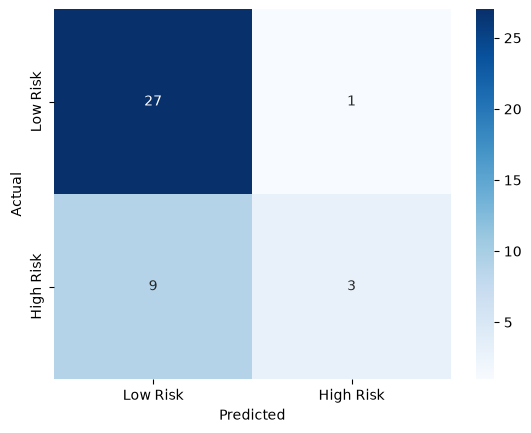

In [25]:
sns.heatmap(cm, annot=True,cmap='Blues', xticklabels=["Low Risk","High Risk"], yticklabels=["Low Risk","High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")


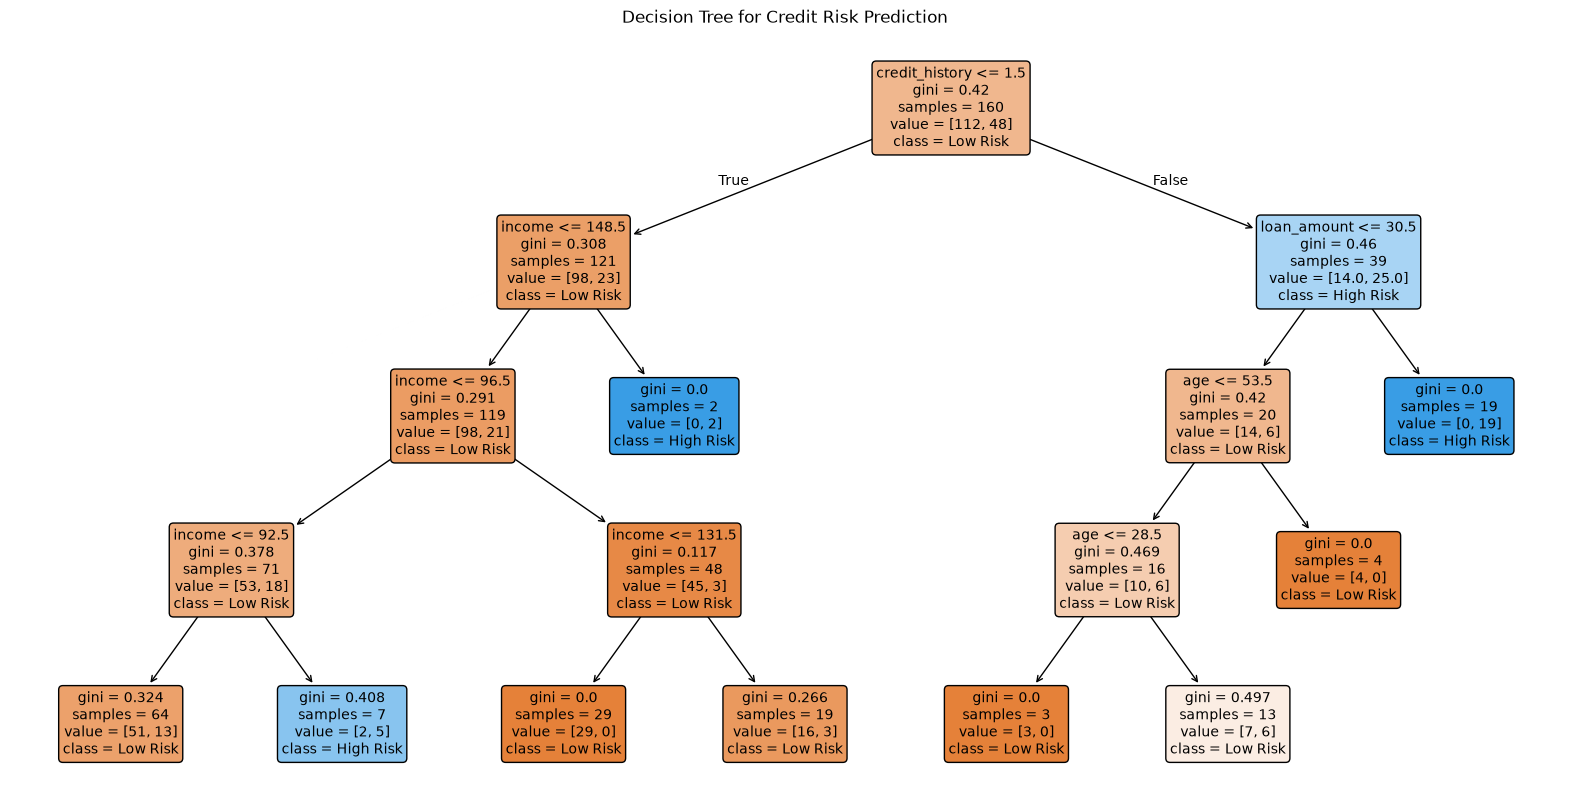

In [28]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low Risk","High Risk"],
    filled= True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Credit Risk Prediction")

plt.show()

In [29]:
importance = pd.DataFrame({"Feature": X.columns,
                           "Importance":model.feature_importances_})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

          Feature  Importance
2  credit_history    0.373563
3     loan_amount    0.297376
1          income    0.268692
0             age    0.060370


In [31]:
new_applicant = pd.DataFrame([[
    35,
    60000,
    20000,
    750
]], columns=X.columns)

In [32]:
prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("Prediction: High Risk")
else:
    print("Prediction: Low Risk")

Prediction: High Risk
